In [1]:
from pathlib import Path
import os
import sys

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import copernicusmarine
import shutil

import cartopy.crs as ccrs
import cartopy.feature as cfeature

c:\Users\pesen\Documents\UCL Masters Coursework\Masters Project SWOT\swot_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from display_tracks import display_1D_tracks, get_spatial_density
from copernicus_pipeline import fetch_and_store_satellites, load_experiment_dataset, combine_for_drf, process_and_split_dataframe, store_tensors

In [3]:
example_experiment = {
    "name": "example_experiment",
    "satellites": [
        {"name": "", "freq": ""},
        {"name": "", "freq": ""}
        # etc.
    ],
    "start_date": "2024-01-01",
    "end_date": "2024-01-02",
    "variables": ["sla_filtered", ""]#etc.
}

In [4]:
test_experiment1 = {
    "name": "test_experiment1",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"}
    ],
    "start_date": "2023-11-07",
    "end_date": "2023-11-13",
    "variables": ["sla_filtered"]
}

In [5]:
test_experiment2 = {
    "name": "test_experiment2",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"}
    ],
    "start_date": "2024-01-01",
    "end_date": "2024-01-15",
    "variables": ["sla_filtered"]
}

In [6]:
baseline_experiment = {
    "name": "baseline_jason_cryosat",
    "satellites": [
        {"name": "jason3_interleaved", "freq": "1hz"},
        {"name": "cryosat2", "freq": "1hz"}
    ],
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "variables": ["sla_filtered"]
}

In [7]:
all_sats_1_day_experiment = {
    "name": "all_sats_1_day_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"},
        {"name": "jason3_LRO", "freq": "1hz"},
        {"name": "cryosat2", "freq": "1hz"},
        {"name": "sentinel3a", "freq": "1hz"}
    ],
    "start_date": "2026-06-01",
    "end_date": "2026-06-02",
    "variables": ["sla_filtered"]
}

In [8]:
all_sats_15_days_experiment = {
    "name": "all_sats_15_days_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"},
        {"name": "jason3_interleaved", "freq": "1hz"},
        {"name": "jason3_LRO", "freq": "1hz"},
        {"name": "cryosat2", "freq": "1hz"},
        {"name": "sentinel3a", "freq": "1hz"}
    ],
    "start_date": "2026-06-01",
    "end_date": "2026-06-15",
    "variables": ["sla_filtered"]
}

In [9]:
small_experiment = {
    "name": "small_experiment",
    "satellites": [
        {"name": "swot_nadir", "freq": "1hz"}
    ],
    "start_date": "2024-01-01T00:00:00",
    "end_date": "2024-01-01T01:00:00",
    "variables": ["sla_filtered"]
}

Running Locally.
Skipping swot_nadir: Dataset already exists at G:\My Drive\SWOT Project\data\zarr files\swot_nadir\swot_nadir_1hz_2024-01-01T00-00-00_2024-01-01T01-00-00.zarr
Running Locally.


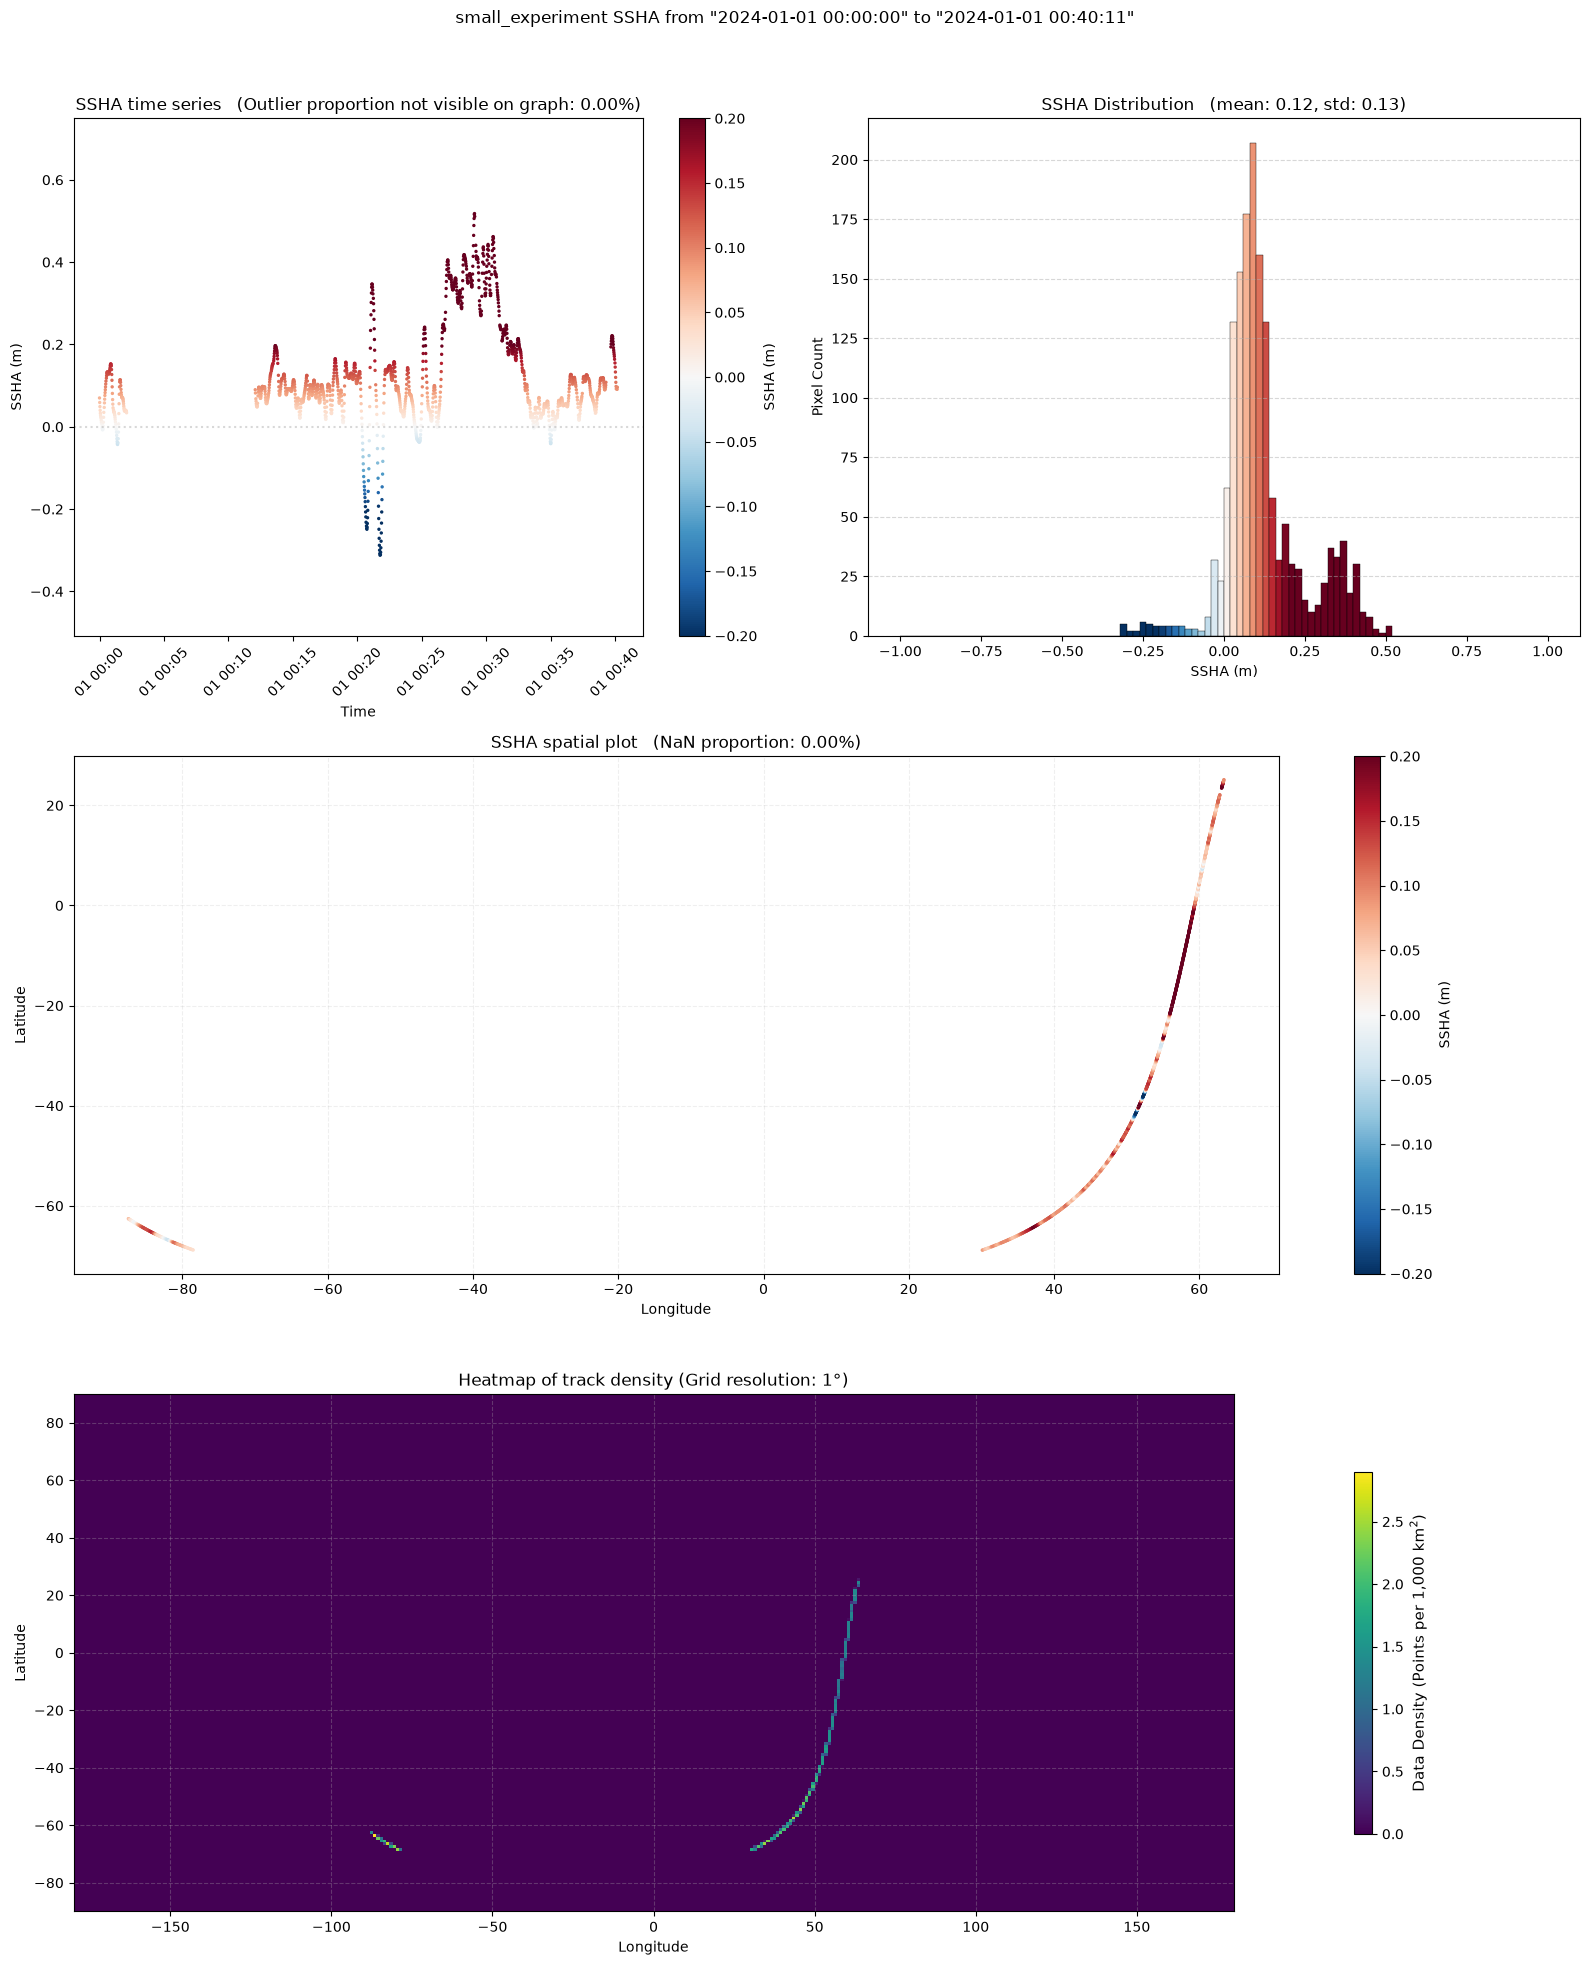

,time,sla_filtered,latitude,longitude,satellite
0,2024-01-01 00:00:00,0.070,-62.579790,-87.447250,swot_nadir
1,2024-01-01 00:00:01,0.059,-62.636375,-87.387375,swot_nadir
2,2024-01-01 00:00:02,0.049,-62.692932,-87.327250,swot_nadir
3,2024-01-01 00:00:03,0.040,-62.749462,-87.266880,swot_nadir
4,2024-01-01 00:00:04,0.033,-62.805958,-87.206260,swot_nadir
...,...,...,...,...,...
1568,2024-01-01 00:40:04,0.108,24.754627,63.322340,swot_nadir
1569,2024-01-01 00:40:05,0.098,24.817370,63.334450,swot_nadir
1570,2024-01-01 00:40:06,0.092,24.880110,63.346580,swot_nadir
1571,2024-01-01 00:40:10,0.091,25.068314,63.383070,swot_nadir


Running Locally.
Saved small_experiment to G:\My Drive\SWOT Project\data\pytorch tensors\small_experiment.pt


In [10]:
# Set experiment to test
experiment = small_experiment

fetch_and_store_satellites(experiment)

data_dict = load_experiment_dataset(experiment)

ds = combine_for_drf(data_dict, "xarray")

display_1D_tracks(ds, experiment["name"], dot_size=2)

df = combine_for_drf(data_dict, "pandas")

display(df)

processed_tensors = process_and_split_dataframe(df)

store_tensors(processed_tensors, experiment["name"])

